# Tropical Fruits Classification Model

Selamat datang di modul Klasifikasi Buah Tropis! Notebook ini memandu Anda membangun model klasifikasi menggunakan algoritma **K-Nearest Neighbors (KNN)** untuk memprediksi jenis buah tropis berdasarkan kondisi lingkungan dan tanah.

## 1. Persiapan Library

Langkah pertama adalah mengimpor semua library Python yang dibutuhkan, seperti `pandas` untuk manipulasi data, `matplotlib` dan `seaborn` untuk visualisasi, serta `scikit-learn` untuk *Machine Learning*.

In [56]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, f1_score, recall_score,
    classification_report
)

## 2. Data Loading

### 2.1. Load Dataset

Membaca dataset ke dalam DataFrame pandas untuk memudahkan manipulasi dan analisis data.

In [57]:
data = pd.read_csv("../dataset/crop_buah_tropis.csv")
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,52,108,48,14.000000,93.568505,7.790062,204.723747,papaya
1,50,85,53,14.000000,99.000000,6.616980,194.919741,papaya
2,84,99,54,28.235199,86.995720,6.518205,89.910024,banana
3,106,14,50,26.178716,80.094251,7.075525,41.342748,watermelon
4,58,60,56,14.000000,95.009529,6.782712,163.002324,papaya


### 2.2. Pembersihan dan Inspeksi Kolom

Melihat sekilas informasi dataset (tipe data, jumlah entri) dan memastikan nama kolom sesuai. Pada dataset buah tropis ini, target klasifikasi kita ada di kolom `label` (4 jenis buah).

In [58]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2400 non-null   int64  
 1   P            2400 non-null   int64  
 2   K            2400 non-null   int64  
 3   temperature  2400 non-null   float64
 4   humidity     2400 non-null   float64
 5   ph           2400 non-null   float64
 6   rainfall     2400 non-null   float64
 7   label        2400 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 150.1 KB


### 2.3. Statistik Deskriptif

Melihat ringkasan statistik (rata-rata, nilai minimum/maksimum, kuartil) dari fitur-fitur numerik untuk memahami distribusi dasar dari data.

In [59]:
data.describe(include='all')

,N,P,K,temperature,humidity,ph,rainfall,label
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,papaya
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,600
mean,68.808750,47.548750,45.245833,29.193165,76.783290,6.238907,103.205386,NaN
std,43.690388,31.039046,12.534853,7.074904,17.607827,0.992082,79.739767,NaN
min,0.000000,0.000000,0.000000,14.000000,20.000000,3.500000,15.000000,NaN
25%,33.750000,22.000000,36.000000,25.122413,62.806735,5.757264,56.765156,NaN
50%,70.000000,45.500000,48.000000,27.781313,82.872013,6.392802,92.989921,NaN
75%,102.000000,72.000000,53.000000,32.570404,90.574305,6.815372,111.670507,NaN


### 2.4. Deteksi Missing Values

Memeriksa apakah terdapat nilai yang hilang (*missing values/NaN*) pada dataset. Data yang hilang perlu ditangani (misalnya diisi atau dihapus) agar tidak mengganggu proses training model.

In [60]:
data_null = data.isnull().sum()
data_null[data_null > 0]

Series([], dtype: int64)

### 2.5. Deteksi Data Duplikat

Memeriksa dan menghapus baris data yang duplikat untuk memastikan model belajar dari informasi yang unik dan bervariasi.

In [61]:
duplicate = data. duplicated()
print(data[duplicate])

Empty DataFrame
Columns: [N, P, K, temperature, humidity, ph, rainfall, label]
Index: []


### 2.6. Pembersihan Fitur dan Distribusi Label

Memastikan fitur sudah bersih dan melihat sekilas komposisi setiap kelas pada kolom target (`label`).

In [62]:
jumlah_unik = data['label'].nunique()
print(f"Jumlah label unik: {jumlah_unik}")

print(data['label'].value_counts())

Jumlah label unik: 4
label
papaya        600
banana        600
watermelon    600
mango         600
Name: count, dtype: int64


---
## 3. Exploratory Data Analysis (EDA)

### 3.1. Distribusi Fitur Numerik (Histogram Grid)

Menganalisis bentuk distribusi frekuensi dari setiap fitur numerik (N, P, K, temperature, humidity, pH, rainfall) menggunakan grid subplot.

**Konsep:**
- Histogram menampilkan sebaran frekuensi nilai fitur
- Kurva KDE (Kernel Density Estimation) memberikan gambaran estimasi bentuk distribusi (normal, skewed/miring, bimodal)

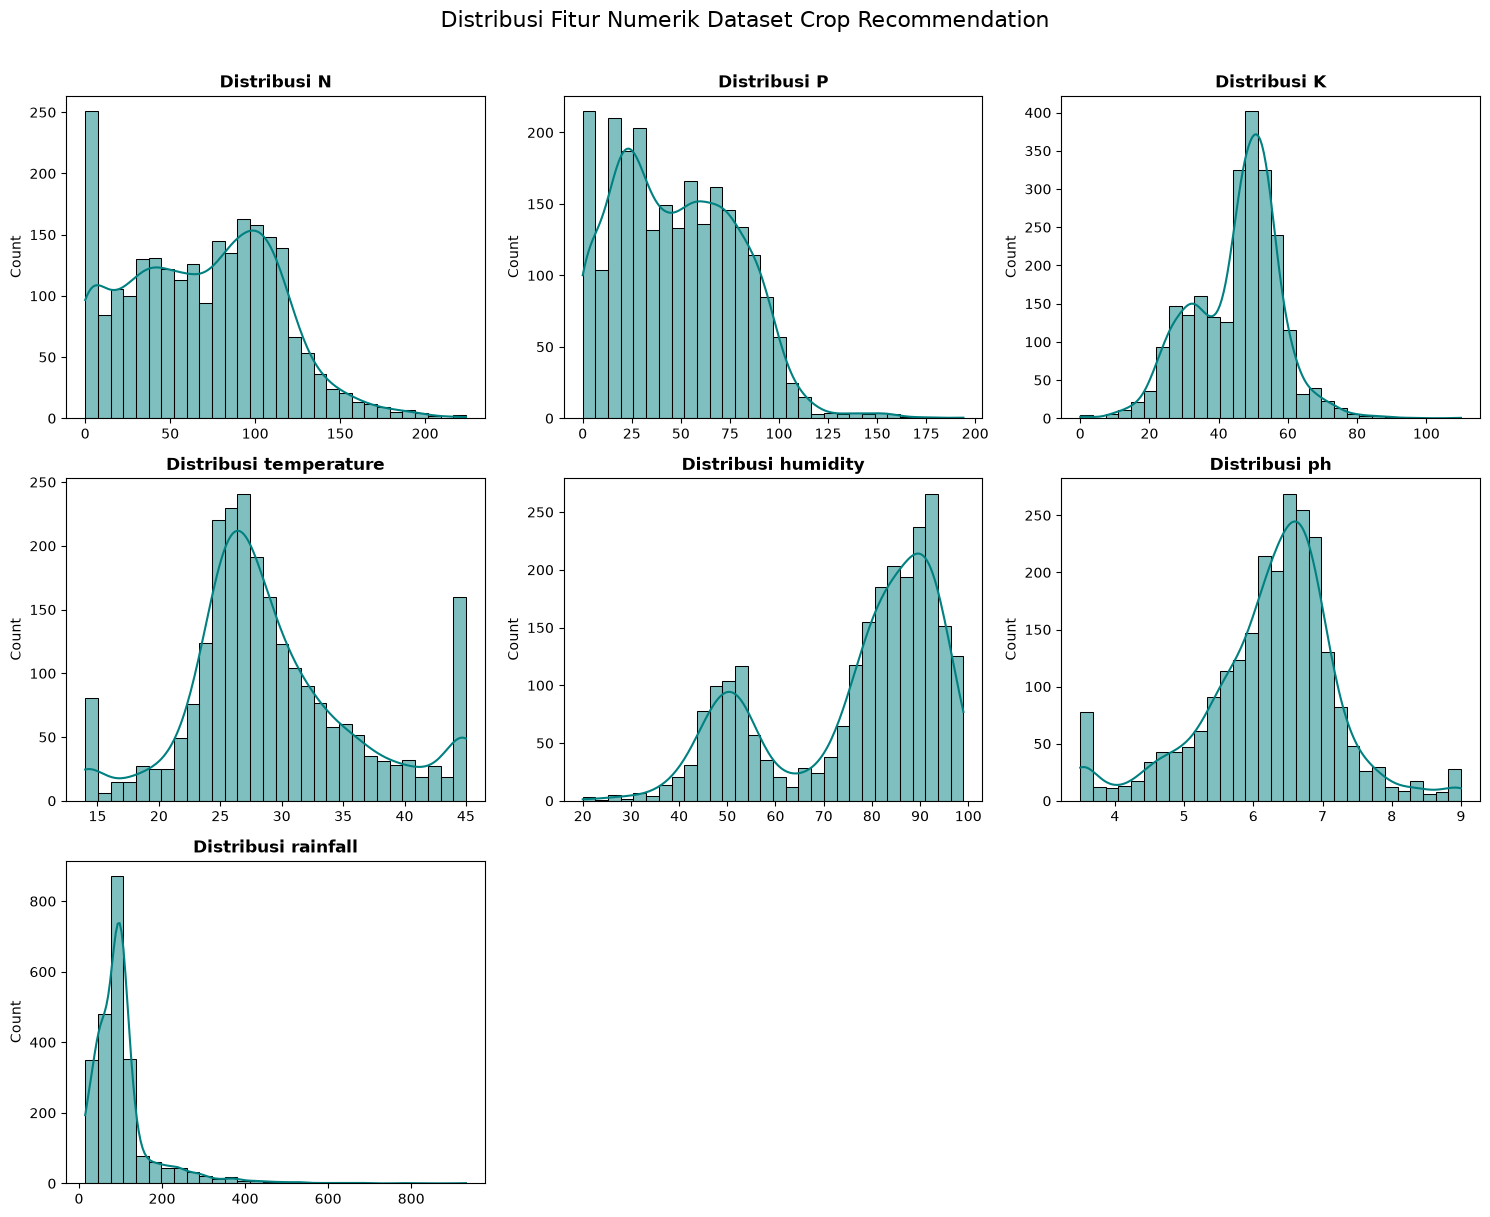

In [63]:
num_features = data.select_dtypes(include=[np.number])
num_cols = num_features.columns

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data[col], bins=30, kde=True, color='teal', ax=axes[i])
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

# Hapus subplot kosong jika ada
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur Numerik Dataset Crop Recommendation', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 3.2. Deteksi Outlier (Boxplot Grid)

Melihat sebaran data dan mengidentifikasi nilai ekstrem (*outliers*) menggunakan Box Plot yang ditampilkan dalam satu grid rapi.

**Konsep:**
- Garis tengah box = Median (Q2)
- Batas bawah dan atas box = Kuartil 1 (Q1) dan Kuartil 3 (Q3)
- Titik di luar whisker (gantung) = potensi Outlier

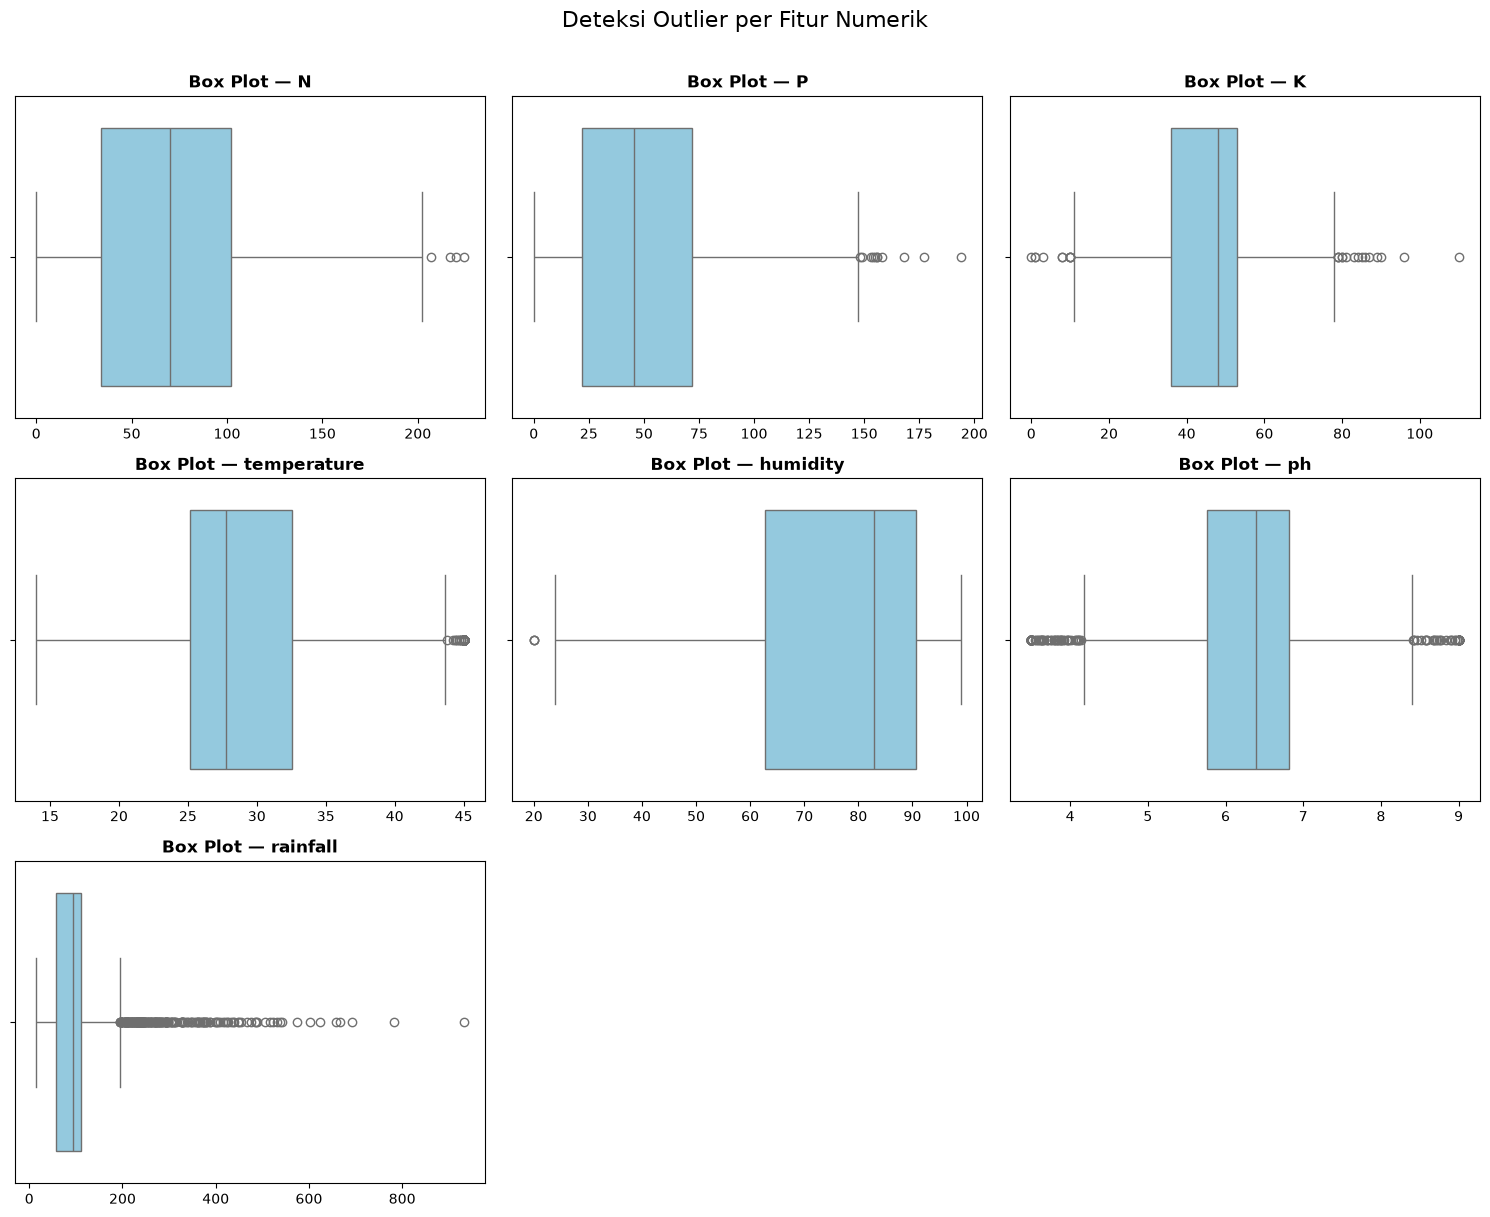

In [64]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=data[col], color='skyblue', ax=axes[i])
    axes[i].set_title(f'Box Plot — {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Deteksi Outlier per Fitur Numerik', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 3.3. Matriks Korelasi

Menganalisis hubungan korelasi linear antar fitur numerik menggunakan Heatmap Korelasi Pearson.

**Konsep:**
- Nilai mendekati +1 → korelasi positif kuat
- Nilai mendekati -1 → korelasi negatif kuat
- Nilai mendekati 0 → tidak ada hubungan linear

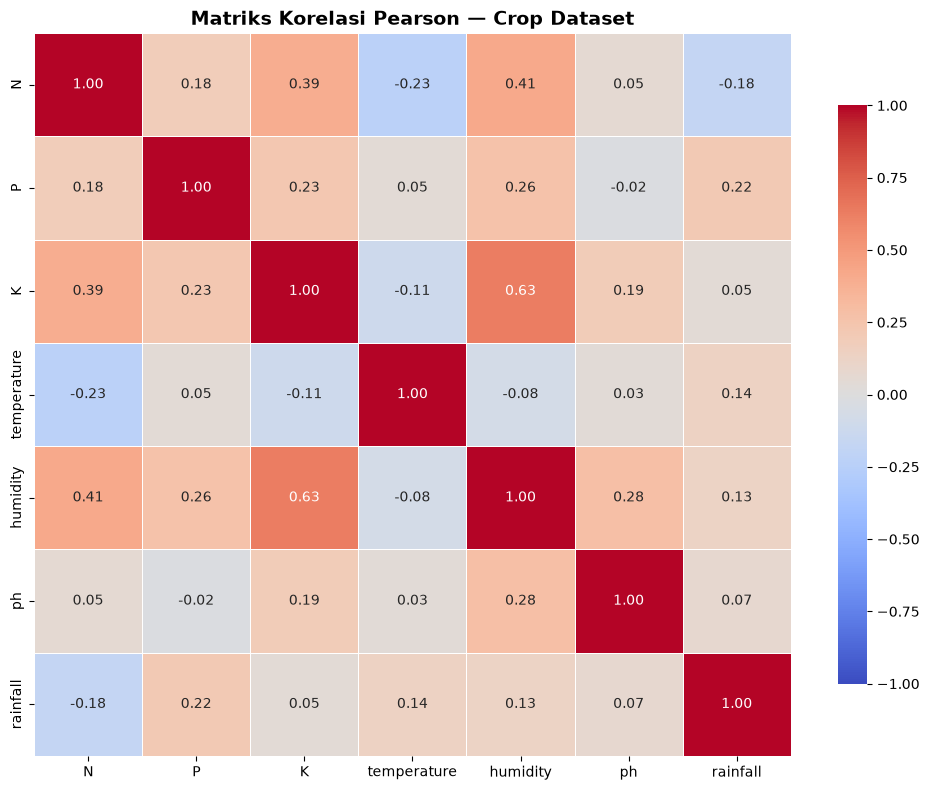

In [65]:
plt.figure(figsize=(10, 8))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriks Korelasi Pearson — Crop Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4. Distribusi Label/Target

Mengecek keseimbangan jumlah sampel untuk setiap jenis tanaman (22 jenis tanaman).

/tmp/ipykernel_376667/3777631117.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='label', data=data, palette='viridis',


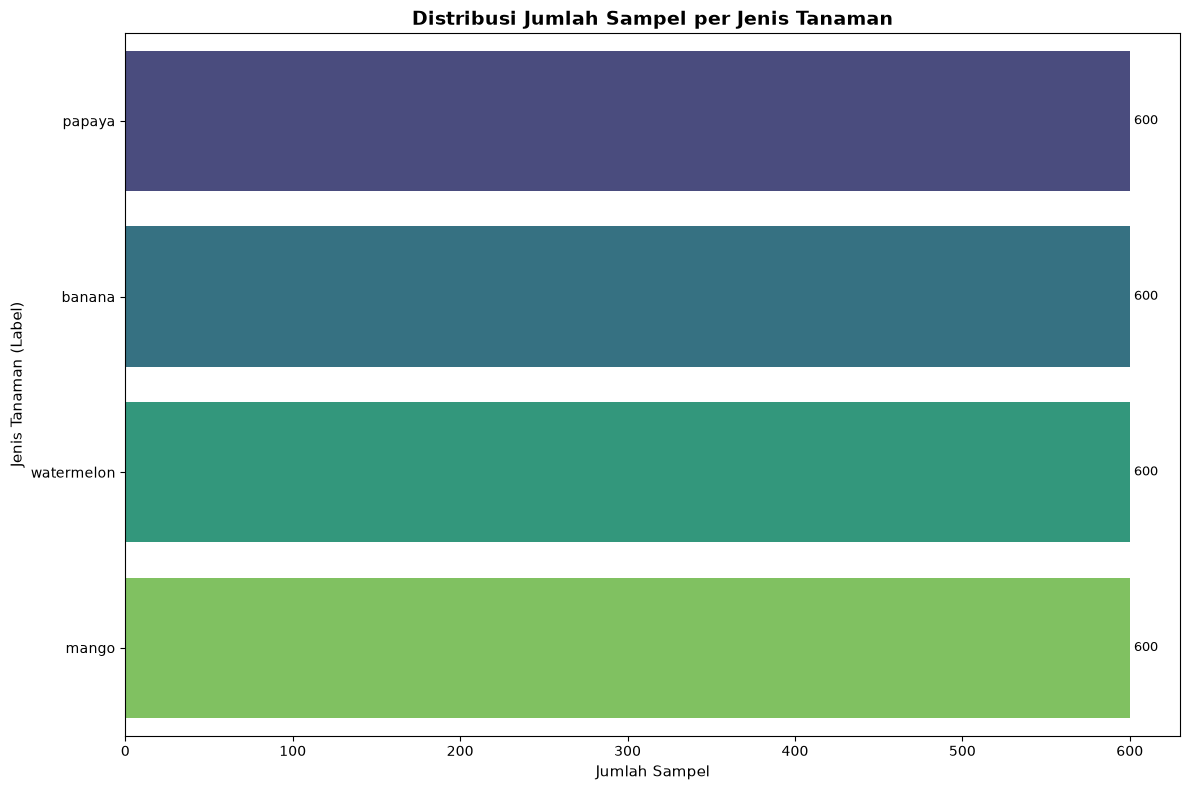

In [66]:
plt.figure(figsize=(12, 8))
ax = sns.countplot(y='label', data=data, palette='viridis',
                   order=data['label'].value_counts().index)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

plt.title('Distribusi Jumlah Sampel per Jenis Tanaman', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Sampel', fontsize=11)
plt.ylabel('Jenis Tanaman (Label)', fontsize=11)
plt.tight_layout()
plt.show()

### 3.5. Rata-Rata Karakteristik Lingkungan per Tanaman

Membuat **Heatmap Rata-Rata** untuk melihat profil kebutuhan tanah dan cuaca ideal bagi masing-masing jenis tanaman secara ringkas dan intuitif.

**Konsep:**
- Setiap sel menunjukkan nilai rata-rata fitur untuk tanaman tersebut
- Memudahkan kita memahami syarat tumbuh tiap tanaman (misal: mana tanaman yang butuh curah hujan tinggi, mana yang butuh Nitrogen tinggi)

### 3.6. Analisis Hubungan Nutrisi Tanah (N vs P vs K)

Memvisualisasikan hubungan antara unsur hara Nitrogen (N) dan Fosfor (P) untuk beberapa jenis tanaman utama.

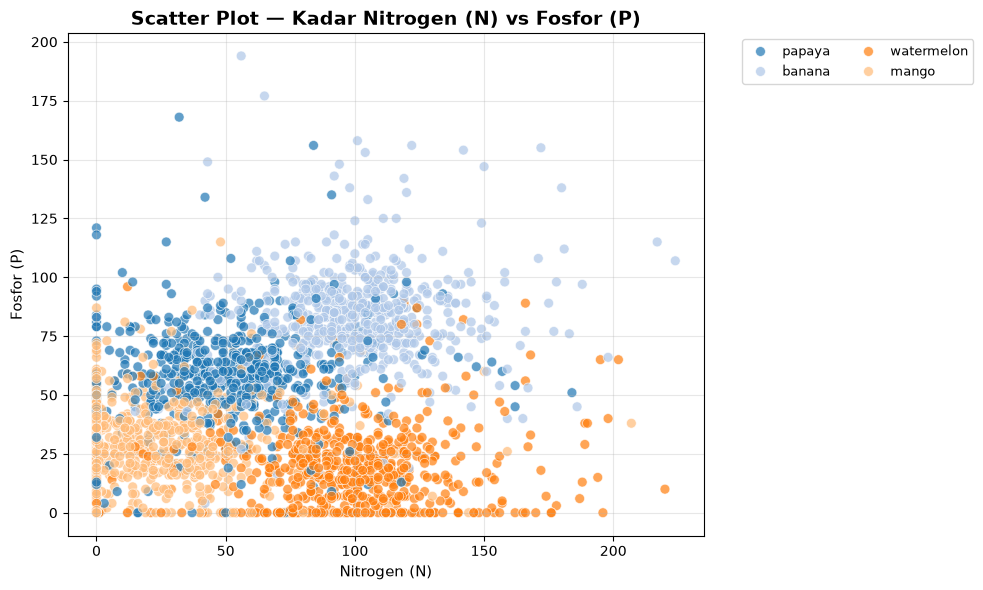

In [67]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='N', y='P', hue='label', data=data, palette='tab20', alpha=0.7, s=50)
plt.title('Scatter Plot — Kadar Nitrogen (N) vs Fosfor (P)', fontsize=14, fontweight='bold')
plt.xlabel('Nitrogen (N)', fontsize=11)
plt.ylabel('Fosfor (P)', fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.7. Analisis Iklim (Suhu vs Curah Hujan)

Memvisualisasikan hubungan antara Suhu (*Temperature*) dan Curah Hujan (*Rainfall*) terhadap jenis tanaman.

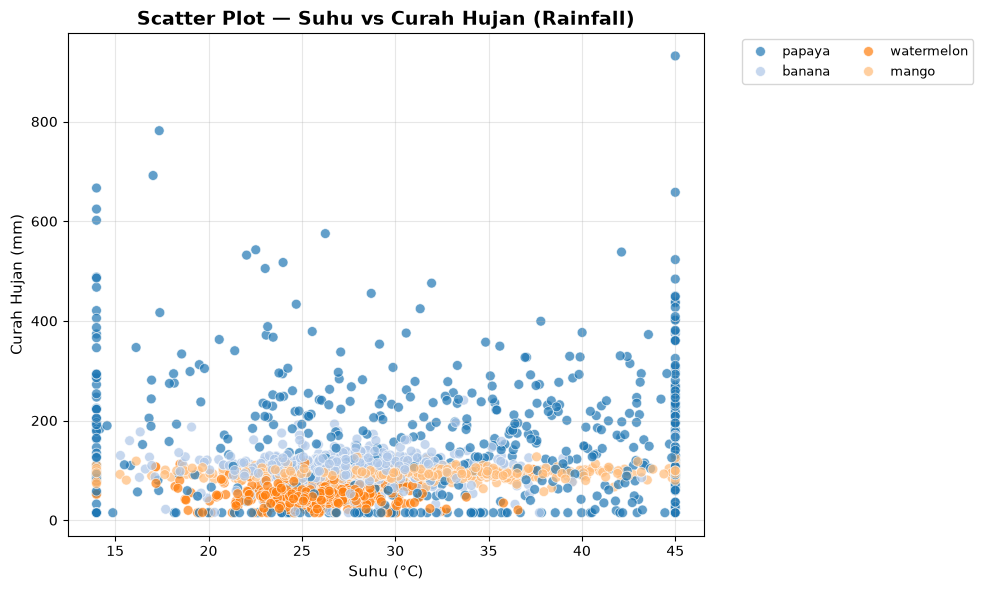

In [68]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temperature', y='rainfall', hue='label', data=data, palette='tab20', alpha=0.7, s=50)
plt.title('Scatter Plot — Suhu vs Curah Hujan (Rainfall)', fontsize=14, fontweight='bold')
plt.xlabel('Suhu (°C)', fontsize=11)
plt.ylabel('Curah Hujan (mm)', fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.8. Analisis Tingkat Keasaman Tanah (pH)

Melihat sebaran tingkat keasaman tanah (pH) yang cocok untuk setiap tanaman.

/tmp/ipykernel_376667/689578316.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='ph', data=data, palette='Set3')


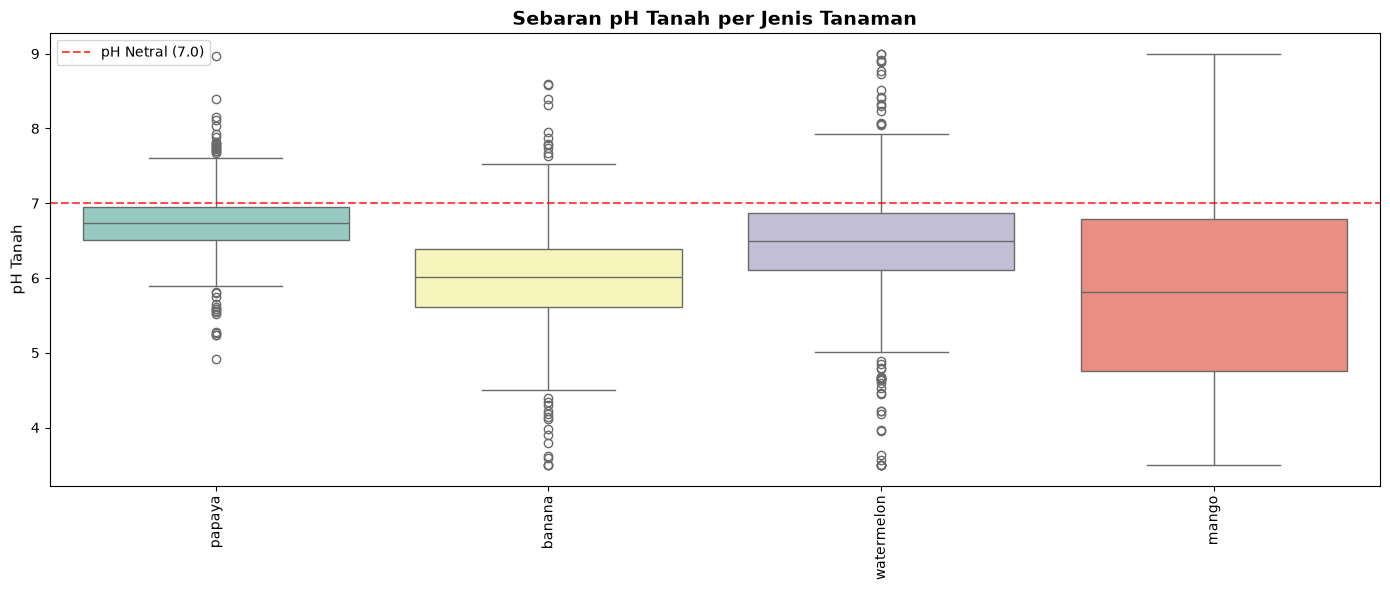

In [69]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='label', y='ph', data=data, palette='Set3')
plt.title('Sebaran pH Tanah per Jenis Tanaman', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('pH Tanah', fontsize=11)
plt.xticks(rotation=90)
plt.axhline(y=7.0, color='red', linestyle='--', alpha=0.7, label='pH Netral (7.0)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 4. Data Preprocessing

### 4.1. Pisahkan Fitur dan Target

Memisahkan kolom fitur (X) yang akan digunakan untuk memprediksi, dan kolom target/label (y) yang ingin diprediksi.

In [70]:
X = data.drop(columns='label').copy()
y = data['label']

### 4.2. Penanganan Outlier dengan Metode Kuartil (IQR - Interquartile Range)

Mengatasi nilai ekstrem (*outliers*) menggunakan metode rentang antar-kuartil (**IQR**). Nilai di luar batas bawah dan batas atas akan dibatasi (*capping / winsorizing*) agar tidak merusak distribusi data dan pembobotan model.

**Rumus IQR:**
- $Q_1$ = Kuartil 1 (Persentil 25)
- $Q_3$ = Kuartil 3 (Persentil 75)
- $IQR = Q_3 - Q_1$
- $\text{Lower Bound} = Q_1 - 1.5 \times IQR$
- $\text{Upper Bound} = Q_3 + 1.5 \times IQR$

> 💡 **Capping (Winsorizing):** Mengganti nilai $< \text{Lower Bound}$ menjadi $\text{Lower Bound}$, dan nilai $> \text{Upper Bound}$ menjadi $\text{Upper Bound}$ tanpa menghapus baris data.

In [71]:
# Penanganan Outlier dengan metode IQR Capping
num_cols = X.columns

print("Batas IQR untuk setiap fitur:")
for col in num_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Hitung jumlah outlier sebelum capping
    n_outliers = ((X[col] < lower_bound) | (X[col] > upper_bound)).sum()
    print(f"   - {col:12s}: Q1={Q1:6.2f}, Q3={Q3:6.2f}, IQR={IQR:6.2f} | Outliers={n_outliers:2d} | Range: [{lower_bound:6.2f}, {upper_bound:6.2f}]")
    
    # Capping nilai di luar batas IQR
    X[col] = np.clip(X[col], lower_bound, upper_bound)

print("\nPenanganan outlier dengan metode IQR Capping selesai!")

Batas IQR untuk setiap fitur:
   - N           : Q1= 33.75, Q3=102.00, IQR= 68.25 | Outliers= 4 | Range: [-68.62, 204.38]
   - P           : Q1= 22.00, Q3= 72.00, IQR= 50.00 | Outliers=11 | Range: [-53.00, 147.00]
   - K           : Q1= 36.00, Q3= 53.00, IQR= 17.00 | Outliers=25 | Range: [ 10.50,  78.50]
   - temperature : Q1= 25.12, Q3= 32.57, IQR=  7.45 | Outliers=161 | Range: [ 13.95,  43.74]
   - humidity    : Q1= 62.81, Q3= 90.57, IQR= 27.77 | Outliers= 3 | Range: [ 21.16, 132.23]
   - ph          : Q1=  5.76, Q3=  6.82, IQR=  1.06 | Outliers=153 | Range: [  4.17,   8.40]
   - rainfall    : Q1= 56.77, Q3=111.67, IQR= 54.91 | Outliers=218 | Range: [-25.59, 194.03]

Penanganan outlier dengan metode IQR Capping selesai!


#### Visualisasi Box Plot Setelah Penanganan Outlier

Menampilkan ulang Box Plot dari seluruh fitur numerik setelah dilakukan penanganan outlier dengan metode IQR Capping.

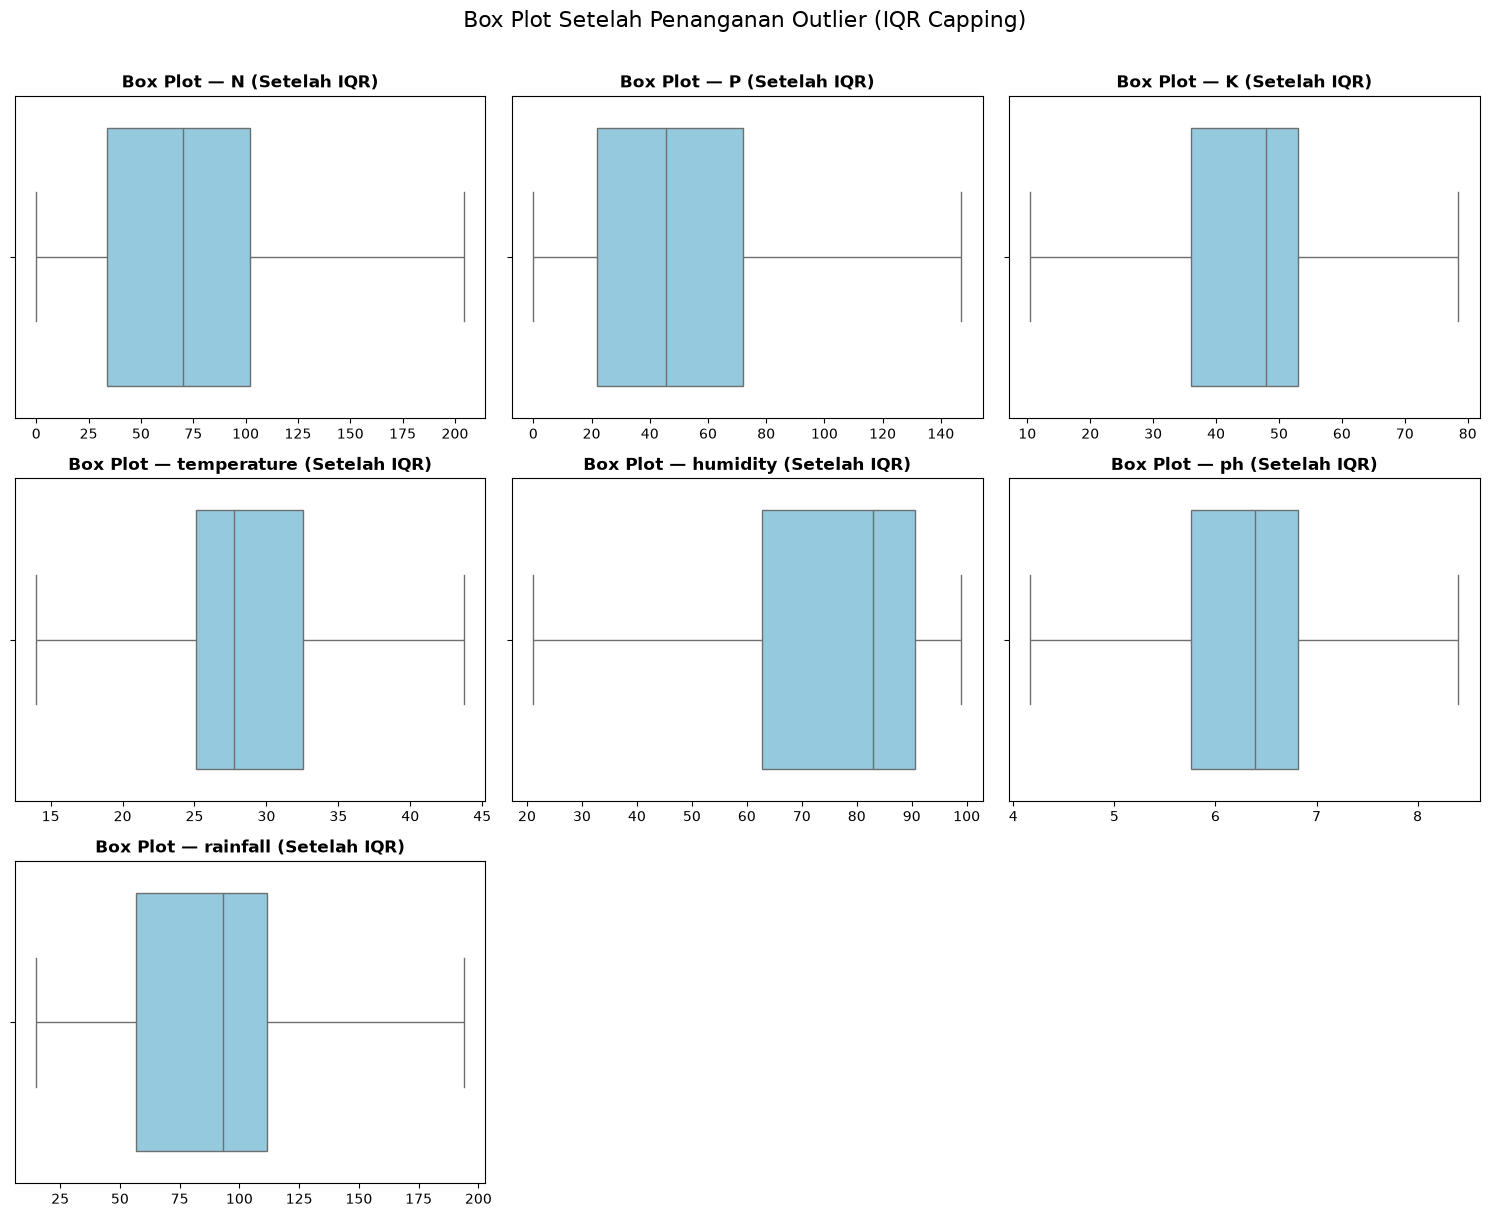

In [72]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.boxplot(x=X[col], color='skyblue', ax=axes[i])
    axes[i].set_title(f'Box Plot — {col} (Setelah IQR)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(len(X.columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Box Plot Setelah Penanganan Outlier (IQR Capping)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 4.3. Standardisasi Fitur (StandardScaler)

Mengubah skala fitur agar memiliki rata-rata 0 dan standar deviasi 1.

In [73]:
scaler = StandardScaler()

X = scaler.fit_transform(X)
X

array([[-0.38493211,  1.96453707,  0.22576551, ...,  0.95364792,
         1.68732126,  2.13931521],
       [-0.43079092,  1.21786311,  0.63154489, ...,  1.26226356,
         0.39766985,  2.13931521],
       [ 0.34880875,  1.67236031,  0.71270077, ...,  0.5801846 ,
         0.28907928, -0.07159523],
       ...,
       [-0.79766135, -0.01577213, -1.96544317, ..., -1.61117775,
        -1.39436705,  0.0807487 ],
       [-0.2702851 , -0.21055665, -1.64081967, ..., -1.95515342,
         1.23969977, -0.011901  ],
       [-0.2473557 , -0.04823622, -0.098858  , ...,  0.85118676,
        -1.02017941, -0.85358763]], shape=(2400, 7))

### 4.4. Encoding Label (LabelEncoder)

Mengubah label kelas berupa teks (kategorikal) menjadi angka (numerik).

In [74]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(y)

[2 2 0 ... 1 1 0]


### 4.5. Bagi Data Latih dan Uji (80:20)

Membagi dataset menjadi 80% data latih dan 20% data uji.

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

print(f"Train set shape: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Test set shape: X_test = {X_test.shape}, y_test = {y_test.shape}")

Train set shape: X_train = (1920, 7), y_train = (1920,)
Test set shape: X_test = (480, 7), y_test = (480,)


---
## 5. Model Training

Melatih model **K-Nearest Neighbors (KNN)** menggunakan data latih yang telah diproses.

In [76]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

print("Training model KNN selesai.")

Training model KNN selesai.


---
## 6. Model Evaluation

Mengevaluasi performa model KNN menggunakan data uji. Metrik yang digunakan meliputi Accuracy, Precision, Recall, F1-Score, serta Confusion Matrix.

==== K-Nearest Neighbors (KNN) ====
Accuracy  : 0.9750
Precision : 0.9751
Recall    : 0.9750
F1-Score  : 0.9750

Classification Report:
              precision    recall  f1-score   support

      banana       0.97      0.97      0.97       120
       mango       1.00      0.99      1.00       120
      papaya       0.98      0.98      0.98       120
  watermelon       0.95      0.96      0.95       120

    accuracy                           0.97       480
   macro avg       0.98      0.98      0.98       480
weighted avg       0.98      0.97      0.98       480



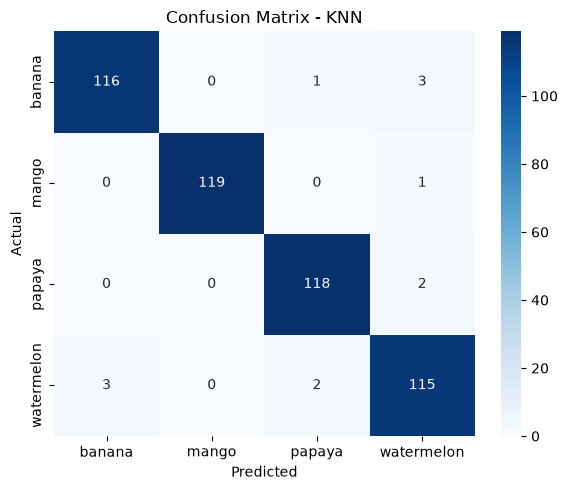

In [77]:
label_names = label_encoder.classes_
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print("==== K-Nearest Neighbors (KNN) ====")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

---
## 7. Detail Metrik Model (TP, FP, FN, TN)

Mengekstrak komponen dasar Confusion Matrix: True Positive, False Positive, False Negative, dan True Negative dari model KNN.

In [78]:
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Untuk multiclass, TP/FP/FN/TN dihitung per kelas lalu dijumlah
tp = cm.diagonal().sum()
fp = (cm.sum(axis=0) - cm.diagonal()).sum()
fn = (cm.sum(axis=1) - cm.diagonal()).sum()
tn = cm.sum() - (tp + fp + fn)

print(f"True Positive  (TP): {tp}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Negative  (TN): {tn}")
print()
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred, average='weighted'):.4f}")

True Positive  (TP): 468
False Positive (FP): 12
False Negative (FN): 12
True Negative  (TN): -12

Accuracy  : 0.9750
Precision : 0.9751
Recall    : 0.9750
F1-Score  : 0.9750


---
## 8. Menyimpan Model (Save Model)

Menyimpan model KNN, scaler, dan label encoder ke dalam file `.joblib`.

In [79]:
# Buat folder model jika belum ada
os.makedirs('../model', exist_ok=True)

# Simpan model KNN
joblib.dump(knn, '../model/best_buah_model.joblib')
print("Model KNN berhasil disimpan ke: model/best_buah_model.joblib")

# Simpan scaler
joblib.dump(scaler, '../model/buah_scaler.joblib')
print("Scaler berhasil disimpan ke: model/buah_scaler.joblib")

# Simpan label encoder
joblib.dump(label_encoder, '../model/buah_label_encoder.joblib')
print("Label Encoder berhasil disimpan ke: model/buah_label_encoder.joblib")

Model KNN berhasil disimpan ke: model/best_buah_model.joblib
Scaler berhasil disimpan ke: model/buah_scaler.joblib
Label Encoder berhasil disimpan ke: model/buah_label_encoder.joblib


flow.md
---
## 11. Memuat Model dan Pengujian (Load Model & Testing)

Sekarang kita akan memuat kembali model yang sudah disimpan dan mengujinya dengan data baru untuk membuktikan bahwa model dapat digunakan **tanpa harus melatih ulang**.

**Konsep:**
- `joblib.load()` → memuat objek Python yang telah disimpan sebelumnya
- Alur penggunaan model yang sudah disimpan:
  1. Load model, scaler, dan label encoder dari file
  2. Transformasi data baru menggunakan scaler yang sama (`scaler.transform()`)
  3. Prediksi menggunakan model (`model.predict()`)
  4. Konversi hasil prediksi ke label asli (`label_encoder.inverse_transform()`)

> ⚠️ **Penting:** Gunakan `scaler.transform()` (bukan `fit_transform()`) pada data baru, agar data dinormalisasi dengan parameter yang sama seperti saat training.

In [80]:
# Load model, scaler, dan label encoder
loaded_model = joblib.load('../model/best_buah_model.joblib')
loaded_scaler = joblib.load('../model/buah_scaler.joblib')
loaded_encoder = joblib.load('../model/buah_label_encoder.joblib')

print("Model berhasil dimuat dari: model/best_buah_model.joblib")
print(f"Tipe model: {type(loaded_model).__name__}")
print(f"Label kelas: {list(loaded_encoder.classes_)}")

Model berhasil dimuat dari: model/best_buah_model.joblib
Tipe model: KNeighborsClassifier
Label kelas: ['banana', 'mango', 'papaya', 'watermelon']


### 11.1. Pengujian dengan Data Test Set

Pertama, kita uji model yang dimuat dengan data test set yang sama untuk memastikan hasilnya **identik** dengan model asli.

In [81]:
# Prediksi menggunakan model yang dimuat
y_pred_loaded = loaded_model.predict(X_test)

# Bandingkan dengan prediksi model asli
y_pred_original = knn.predict(X_test)

acc_loaded = accuracy_score(y_test, y_pred_loaded)
acc_original = accuracy_score(y_test, y_pred_original)

print(f"Akurasi model asli     : {acc_original:.4f}")
print(f"Akurasi model dimuat   : {acc_loaded:.4f}")
print()

if acc_loaded == acc_original:
    print("Hasil IDENTIK! Model berhasil disimpan dan dimuat dengan benar.")
else:
    print("Hasil BERBEDA! Ada masalah dalam proses save/load.")

Akurasi model asli     : 0.9750
Akurasi model dimuat   : 0.9750

Hasil IDENTIK! Model berhasil disimpan dan dimuat dengan benar.


### 11.2. Pengujian dengan Data Baru

Sekarang kita coba prediksi menggunakan **data baru yang belum pernah dilihat model**. Ini mensimulasikan penggunaan model di dunia nyata (production).

**Alur:**
1. Buat data baru dalam bentuk DataFrame
2. Transformasi dengan `loaded_scaler.transform()` (⚠️ bukan `fit_transform`!)
3. Prediksi dengan `loaded_model.predict()`
4. Konversi ke label asli dengan `loaded_encoder.inverse_transform()`

In [82]:
# Contoh data baru untuk pengujian (contoh: kondisi tanah untuk buah Mangga/Mango)
# N=20, P=27, K=30, temperature=31.5, humidity=50.2, ph=5.8, rainfall=95.0
data_baru = {
    'N': [20],
    'P': [27],
    'K': [30],
    'temperature': [31.50],
    'humidity': [50.20],
    'ph': [5.80],
    'rainfall': [95.00]
}

df_baru = pd.DataFrame(data_baru)
print("Data input:")
print(df_baru)
print()

# Transformasi data baru menggunakan scaler yang sudah di-load
# Gunakan transform() BUKAN fit_transform()!
data_scaled = loaded_scaler.transform(df_baru)
print("Data setelah di-scale:")
print(data_scaled)
print()

# Prediksi
prediksi = loaded_model.predict(data_scaled)
print(f"Hasil prediksi (numerik): {prediksi}")

# Prediksi jenis buah yang direkomendasikan
prediksi_label = loaded_encoder.inverse_transform(prediksi)
print(f"Buah yang direkomendasikan: {prediksi_label[0]}")

Data input:
    N   P   K  temperature  humidity   ph  rainfall
0  20  27  30         31.5      50.2  5.8      95.0

Data setelah di-scale:
[[-1.11867297 -0.66505384 -1.23504028  0.34656633 -1.51053519 -0.50049372
   0.03648815]]

Hasil prediksi (numerik): [1]
Buah yang direkomendasikan: mango


---
### Ringkasan Save & Load Model

| Komponen | File | Fungsi |
|----------|------|--------|
| Model KNN | `best_buah_model.joblib` | Model klasifikasi KNN yang sudah dilatih |
| Scaler | `buah_scaler.joblib` | StandardScaler untuk transformasi fitur |
| Label Encoder | `buah_label_encoder.joblib` | Konversi label numerik ke nama buah |